In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 11, 'axes.labelsize': 10})

PATH = r'D:\Laravel\Flask-MachineLearning\Data.csv'
df = pd.read_csv(PATH)

DROP_COLS = ['id', 'high_risk_flag', 'focus_score', 'productivity_score']
df = df.drop(columns=DROP_COLS)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded: 3,500 rows x 20 columns


Split Data (Train 80% / Test 20%)

In [3]:
from sklearn.model_selection import train_test_split

TARGET = 'digital_dependence_score'

df['_strat_key'] = df['education_level'].astype(str) + '_' + df['daily_role'].astype(str)
strat_counts = df['_strat_key'].value_counts()
valid_keys = strat_counts[strat_counts >= 2].index
df_filtered = df[df['_strat_key'].isin(valid_keys)].copy()

print(f'Baris sebelum filter : {len(df):,}')
print(f'Baris setelah filter : {len(df_filtered):,}')
print(f'Grup stratify unik   : {df_filtered["_strat_key"].nunique()}')

X = df_filtered.drop(columns=[TARGET, '_strat_key'])
y = df_filtered[TARGET]
strat = df_filtered['_strat_key']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=strat
)

print(f'\nUkuran Train : {X_train.shape}')
print(f'Ukuran Test  : {X_test.shape}')

for col in ['education_level', 'daily_role']:
    train_prop = X_train[col].value_counts(normalize=True).sort_index()
    test_prop = X_test[col].value_counts(normalize=True).sort_index()
    diff = (train_prop - test_prop).abs().max()
    print(f'  {col} — max perbedaan proporsi train vs test: {diff:.4f}')

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

Baris sebelum filter : 3,500
Baris setelah filter : 3,500
Grup stratify unik   : 20

Ukuran Train : (2800, 19)
Ukuran Test  : (700, 19)
  education_level — max perbedaan proporsi train vs test: 0.0007
  daily_role — max perbedaan proporsi train vs test: 0.0014


Encoding

In [4]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

edu_order = ['High School', 'Bachelor', 'Master', 'PhD']
role_order = ['Caregiver/Home', 'Unemployed_Looking', 'Part-time/Shift', 'Student', 'Full-time Employee']

print('Nilai unik education_level:', sorted(X_train['education_level'].unique()))
print('Nilai unik daily_role     :', sorted(X_train['daily_role'].unique()))
print()
print('Urutan ordinal education_level:', edu_order)
print('Urutan ordinal daily_role     :', role_order)

ord_enc = OrdinalEncoder(
    categories=[edu_order, role_order],
    handle_unknown='use_encoded_value', unknown_value=-1
)

ord_cols = ['education_level', 'daily_role']
X_train[ord_cols] = ord_enc.fit_transform(X_train[ord_cols])
X_test[ord_cols] = ord_enc.transform(X_test[ord_cols])

print()
print('Mapping education_level — 0=High School, 1=Bachelor, 2=Master, 3=PhD')
print('Mapping daily_role     — 0=Caregiver/Home, 1=Unemployed_Looking, 2=Part-time/Shift, 3=Student, 4=Full-time Employee')

ohe_cols = ['gender', 'region', 'device_type', 'income_level']
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe_train = ohe.fit_transform(X_train[ohe_cols])
ohe_test = ohe.transform(X_test[ohe_cols])
ohe_feature_names = ohe.get_feature_names_out(ohe_cols)

X_train = X_train.drop(columns=ohe_cols)
X_test = X_test.drop(columns=ohe_cols)

X_train = pd.concat([X_train.reset_index(drop=True), pd.DataFrame(ohe_train, columns=ohe_feature_names)], axis=1)
X_test = pd.concat([X_test.reset_index(drop=True), pd.DataFrame(ohe_test, columns=ohe_feature_names)], axis=1)

print(f'\nShape setelah encoding — Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Kolom baru dari OHE: {list(ohe_feature_names)}')

Nilai unik education_level: ['Bachelor', 'High School', 'Master', 'PhD']
Nilai unik daily_role     : ['Caregiver/Home', 'Full-time Employee', 'Part-time/Shift', 'Student', 'Unemployed_Looking']

Urutan ordinal education_level: ['High School', 'Bachelor', 'Master', 'PhD']
Urutan ordinal daily_role     : ['Caregiver/Home', 'Unemployed_Looking', 'Part-time/Shift', 'Student', 'Full-time Employee']

Mapping education_level — 0=High School, 1=Bachelor, 2=Master, 3=PhD
Mapping daily_role     — 0=Caregiver/Home, 1=Unemployed_Looking, 2=Part-time/Shift, 3=Student, 4=Full-time Employee

Shape setelah encoding — Train: (2800, 27), Test: (700, 27)
Kolom baru dari OHE: ['gender_Male', 'region_Asia', 'region_Europe', 'region_Middle East', 'region_North America', 'region_South America', 'device_type_Laptop', 'device_type_Tablet', 'device_type_iPhone', 'income_level_Low', 'income_level_Lower-Mid', 'income_level_Upper-Mid']


Outlier: IQR Winsorizing

In [5]:
winsor_cols = [
    'device_hours_per_day', 'phone_unlocks', 'notifications_per_day',
    'social_media_mins', 'sleep_hours', 'anxiety_score', 'digital_dependence_score'
]

winsor_bounds = {}

for col in winsor_cols:
    if col not in X_train.columns:
        continue
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    winsor_bounds[col] = (lo, hi)
    n_out_train = ((X_train[col] < lo) | (X_train[col] > hi)).sum()
    n_out_test = ((X_test[col] < lo) | (X_test[col] > hi)).sum()
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col] = X_test[col].clip(lo, hi)
    print(f'{col:<30} | IQR batas [{lo:.2f}, {hi:.2f}] | outlier train={n_out_train}, test={n_out_test}')

Q1_y, Q3_y = y_train.quantile(0.25), y_train.quantile(0.75)
IQR_y = Q3_y - Q1_y
lo_y, hi_y = Q1_y - 1.5*IQR_y, Q3_y + 1.5*IQR_y
n_out_y = ((y_train < lo_y) | (y_train > hi_y)).sum()
y_train = y_train.clip(lo_y, hi_y)
y_test = y_test.clip(lo_y, hi_y)
print(f'\n{TARGET:<30} | IQR batas [{lo_y:.2f}, {hi_y:.2f}] | outlier target train={n_out_y}')
print('\n✅ Winsorizing selesai. Batas disimpan di dict winsor_bounds.')

device_hours_per_day           | IQR batas [-1.62, 15.51] | outlier train=32, test=5
phone_unlocks                  | IQR batas [-40.00, 320.00] | outlier train=18, test=3
notifications_per_day          | IQR batas [-225.88, 827.12] | outlier train=156, test=38
social_media_mins              | IQR batas [-134.50, 405.50] | outlier train=195, test=46
sleep_hours                    | IQR batas [3.80, 10.78] | outlier train=17, test=3
anxiety_score                  | IQR batas [-3.23, 16.06] | outlier train=207, test=59

digital_dependence_score       | IQR batas [-2.20, 73.00] | outlier target train=33

✅ Winsorizing selesai. Batas disimpan di dict winsor_bounds.


Skewness (Log & Sqrt Transform)

Skewness SEBELUM transformasi:
  notifications_per_day       : 1.038
  device_hours_per_day        : 0.705
  social_media_mins           : 1.004
  anxiety_score               : 0.824
  phone_unlocks               : 0.653

Skewness SETELAH transformasi:
  notifications_per_day       : -0.228
  device_hours_per_day        : -0.232
  social_media_mins           : 0.289
  anxiety_score               : -0.253
  phone_unlocks               : 0.115


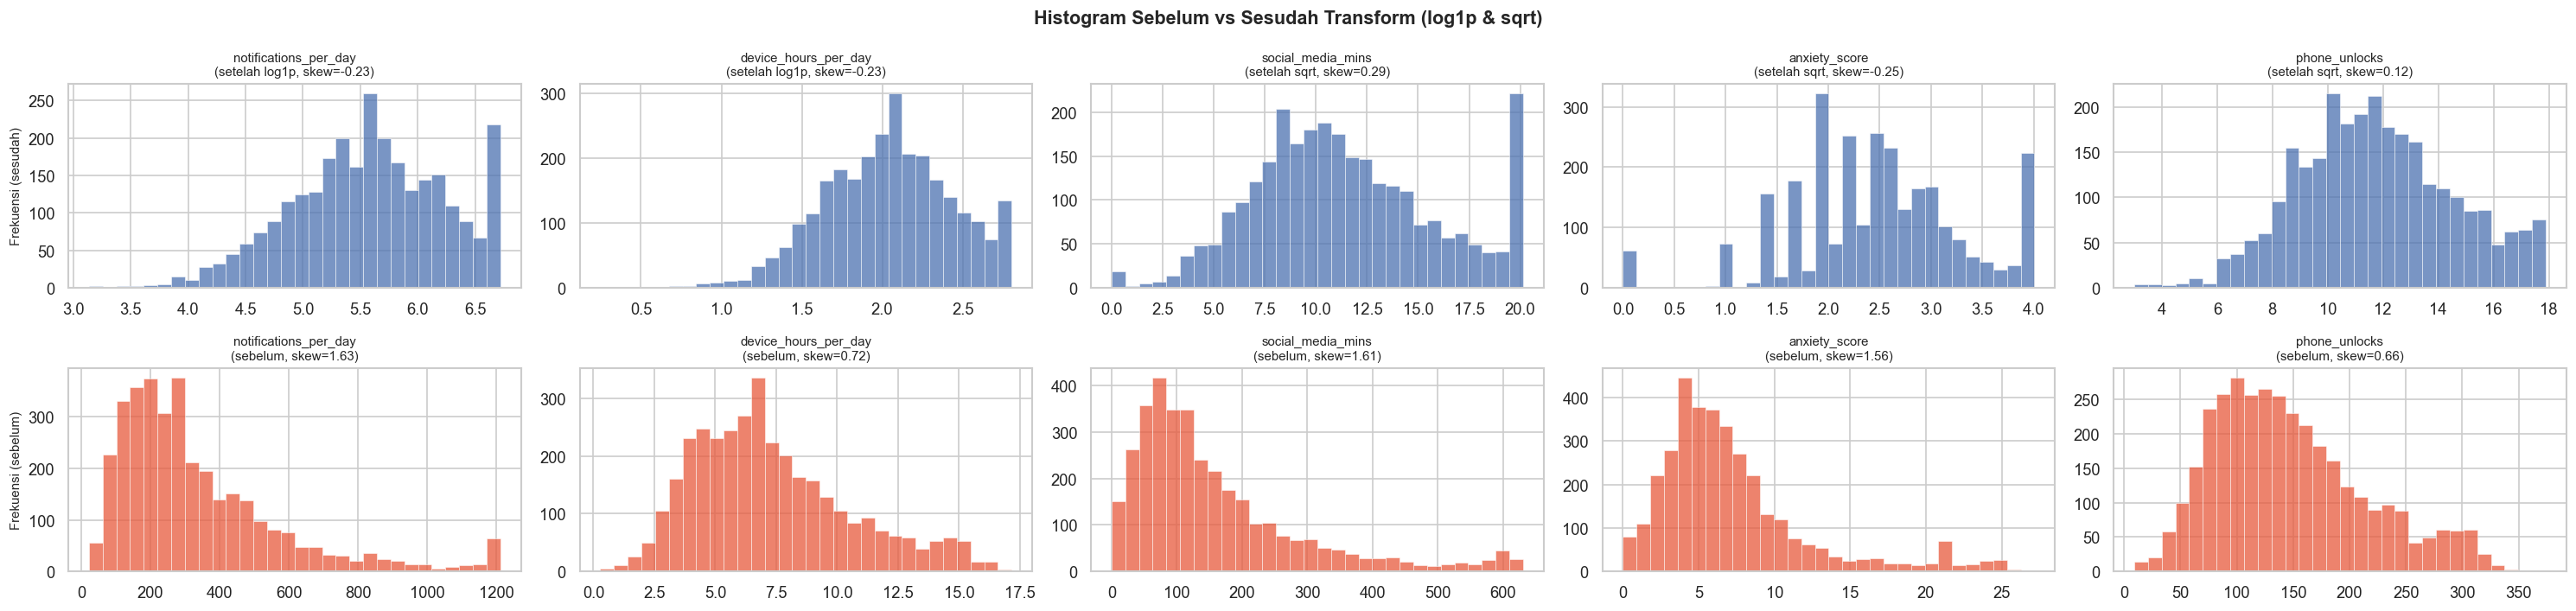

In [6]:
log_cols = ['notifications_per_day', 'device_hours_per_day']
sqrt_cols = ['social_media_mins', 'anxiety_score', 'phone_unlocks']

print('Skewness SEBELUM transformasi:')
for col in log_cols + sqrt_cols:
    if col in X_train.columns:
        print(f'  {col:<28}: {X_train[col].skew():.3f}')

for col in log_cols:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_test[col] = np.log1p(X_test[col])

for col in sqrt_cols:
    if col in X_train.columns:
        X_train[col] = np.sqrt(X_train[col])
        X_test[col] = np.sqrt(X_test[col])

print('\nSkewness SETELAH transformasi:')
for col in log_cols + sqrt_cols:
    if col in X_train.columns:
        print(f'  {col:<28}: {X_train[col].skew():.3f}')

plot_transform_cols = [c for c in log_cols + sqrt_cols if c in X_train.columns]
n_plot = len(plot_transform_cols)
fig, axes = plt.subplots(2, n_plot, figsize=(5 * n_plot, 6))

for i, col in enumerate(plot_transform_cols):
    transform_type = 'log1p' if col in log_cols else 'sqrt'
    axes[0, i].hist(X_train[col], bins=30, color='#4C72B0', alpha=0.75, edgecolor='white', lw=0.4)
    axes[0, i].set_title(f'{col}\n(setelah {transform_type}, skew={X_train[col].skew():.2f})', fontsize=9)
    orig_vals = df_filtered[col] if col in df_filtered.columns else None
    if orig_vals is not None:
        axes[1, i].hist(orig_vals, bins=30, color='#E8593C', alpha=0.75, edgecolor='white', lw=0.4)
        axes[1, i].set_title(f'{col}\n(sebelum, skew={orig_vals.skew():.2f})', fontsize=9)

axes[0, 0].set_ylabel('Frekuensi (sesudah)', fontsize=9)
axes[1, 0].set_ylabel('Frekuensi (sebelum)', fontsize=9)
fig.suptitle('Histogram Sebelum vs Sesudah Transform (log1p & sqrt)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Multikolinearitas (VIF)

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

num_X = X_train.select_dtypes(include=np.number).copy()
num_X_const = add_constant(num_X)

vif_data = pd.DataFrame({
    'Feature': num_X.columns,
    'VIF': [variance_inflation_factor(num_X_const.values, i+1) for i in range(num_X.shape[1])]
}).sort_values('VIF', ascending=False)

print('VIF per fitur:')
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
print(f'\nFitur dengan VIF > 10: {high_vif}')

VIF per fitur:
               Feature      VIF
  device_hours_per_day 5.056382
         phone_unlocks 3.980705
      depression_score 3.174583
      income_level_Low 2.455380
income_level_Lower-Mid 2.421323
         sleep_quality 2.149543
income_level_Upper-Mid 2.146140
          stress_level 1.865500
       happiness_score 1.819858
         region_Europe 1.803417
           region_Asia 1.784405
  region_North America 1.693861
         anxiety_score 1.601334
           sleep_hours 1.597426
  region_South America 1.520137
    device_type_Tablet 1.500025
    device_type_Laptop 1.494143
    device_type_iPhone 1.472263
                   age 1.427568
    region_Middle East 1.411763
           gender_Male 1.195610
       education_level 1.127915
physical_activity_days 1.048578
            daily_role 1.042337
     social_media_mins 1.035234
 notifications_per_day 1.028763
            study_mins 1.006858

Fitur dengan VIF > 10: []


Korelasi ke target — device_hours: 0.849 | phone_unlocks: 0.829
→ Drop: phone_unlocks
Shape setelah drop multikolinear — Train: (2800, 26)


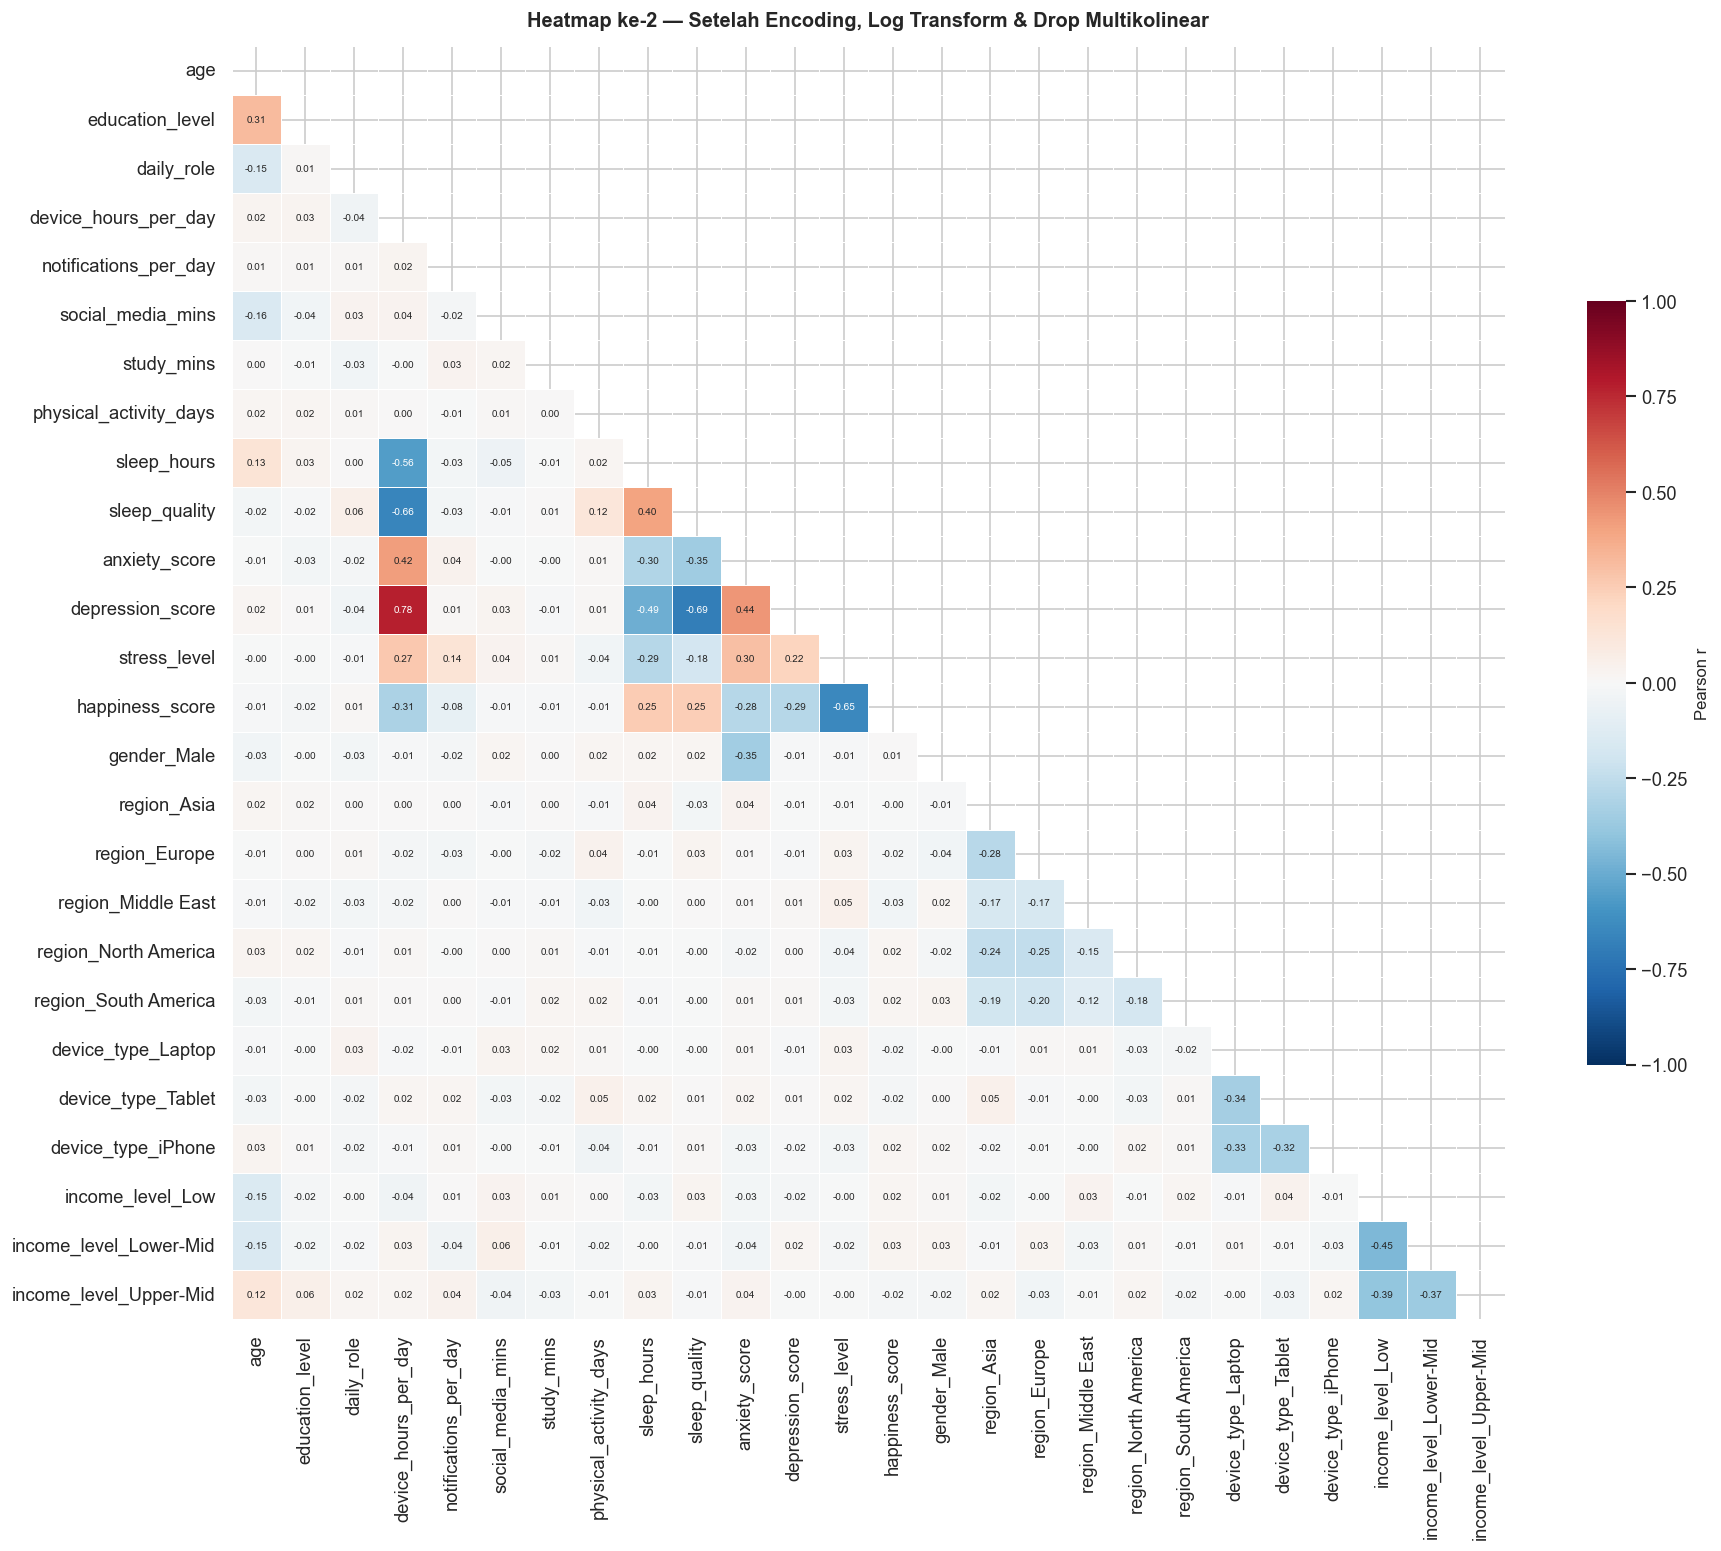

In [8]:
drop_multicolinear = []

if 'phone_unlocks' in X_train.columns and 'device_hours_per_day' in X_train.columns:
    corr_ph = abs(X_train['phone_unlocks'].corr(y_train))
    corr_dev = abs(X_train['device_hours_per_day'].corr(y_train))
    to_drop = 'phone_unlocks' if corr_ph <= corr_dev else 'device_hours_per_day'
    drop_multicolinear.append(to_drop)
    print(f'Korelasi ke target — device_hours: {corr_dev:.3f} | phone_unlocks: {corr_ph:.3f}')
    print(f'→ Drop: {to_drop}')

X_train = X_train.drop(columns=drop_multicolinear, errors='ignore')
X_test = X_test.drop(columns=drop_multicolinear, errors='ignore')
print(f'Shape setelah drop multikolinear — Train: {X_train.shape}')

num_X2 = X_train.select_dtypes(include=np.number).copy()
corr2 = num_X2.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask2 = np.triu(np.ones_like(corr2, dtype=bool))
sns.heatmap(
    corr2, mask=mask2, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, linewidths=0.3, linecolor='white',
    annot_kws={'size': 6}, ax=ax, square=True,
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'}
)
ax.set_title('Heatmap ke-2 — Setelah Encoding, Log Transform & Drop Multikolinear',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Feature Selection

In [9]:
import statsmodels.api as sm

X_ols = sm.add_constant(X_train.select_dtypes(include=np.number))
ols_res = sm.OLS(y_train, X_ols).fit()

pval_df = pd.DataFrame({
    'p_value': ols_res.pvalues,
    'coef': ols_res.params,
}).drop('const', errors='ignore').sort_values('p_value', ascending=False)

pearson_r = X_train.select_dtypes(include=np.number).corrwith(y_train)
pval_df['pearson_r'] = pearson_r.reindex(pval_df.index)
pval_df['|pearson_r|'] = pval_df['pearson_r'].abs()

print('Feature significance summary:')
print(pval_df.round(4).to_string())

drop_insig = pval_df[
    (pval_df['p_value'] > 0.05) & (pval_df['|pearson_r|'] < 0.05)
].index.tolist()

print(f'\nFitur yang di-drop (p>0.05 & |r|<0.05): {drop_insig}')

X_train = X_train.drop(columns=drop_insig, errors='ignore')
X_test = X_test.drop(columns=drop_insig, errors='ignore')
print(f'Shape setelah feature selection — Train: {X_train.shape}, Test: {X_test.shape}')

Feature significance summary:
                        p_value     coef  pearson_r  |pearson_r|
income_level_Lower-Mid   0.9482  -0.0208    -0.0027       0.0027
region_Europe            0.8757  -0.0473    -0.0344       0.0344
study_mins               0.8725   0.0002     0.0093       0.0093
social_media_mins        0.7995   0.0054     0.0255       0.0255
income_level_Upper-Mid   0.7539   0.1001     0.0314       0.0314
physical_activity_days   0.6988  -0.0198    -0.0041       0.0041
age                      0.6740   0.0048     0.0168       0.0168
income_level_Low         0.6502   0.1421    -0.0261       0.0261
daily_role               0.4952  -0.0555    -0.0374       0.0374
device_type_iPhone       0.4370   0.2076    -0.0051       0.0051
device_type_Laptop       0.3983   0.2212    -0.0099       0.0099
region_Middle East       0.3475   0.3603    -0.0026       0.0026
device_type_Tablet       0.2929   0.2780     0.0255       0.0255
region_South America     0.2836   0.3762     0.0099       0.

Standarisasi Fitur Numerik

In [10]:
from sklearn.preprocessing import StandardScaler

ohe_generated_cols = list(ohe_feature_names)
num_scale_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if c not in ohe_generated_cols
]

print(f'Kolom yang akan di-scale ({len(num_scale_cols)}): {num_scale_cols}')

scaler = StandardScaler()
X_train[num_scale_cols] = scaler.fit_transform(X_train[num_scale_cols])
X_test[num_scale_cols] = scaler.transform(X_test[num_scale_cols])

print('\nStatistik X_train setelah scaling (seharusnya mean≈0, std≈1):')
print(X_train[num_scale_cols].describe().loc[['mean', 'std']].round(4))

Kolom yang akan di-scale (8): ['device_hours_per_day', 'notifications_per_day', 'sleep_hours', 'sleep_quality', 'anxiety_score', 'depression_score', 'stress_level', 'happiness_score']

Statistik X_train setelah scaling (seharusnya mean≈0, std≈1):
      device_hours_per_day  notifications_per_day  sleep_hours  sleep_quality  \
mean               -0.0000                -0.0000      -0.0000        -0.0000   
std                 1.0002                 1.0002       1.0002         1.0002   

      anxiety_score  depression_score  stress_level  happiness_score  
mean         0.0000           -0.0000       -0.0000           0.0000  
std          1.0002            1.0002        1.0002           1.0002  


Verifikasi

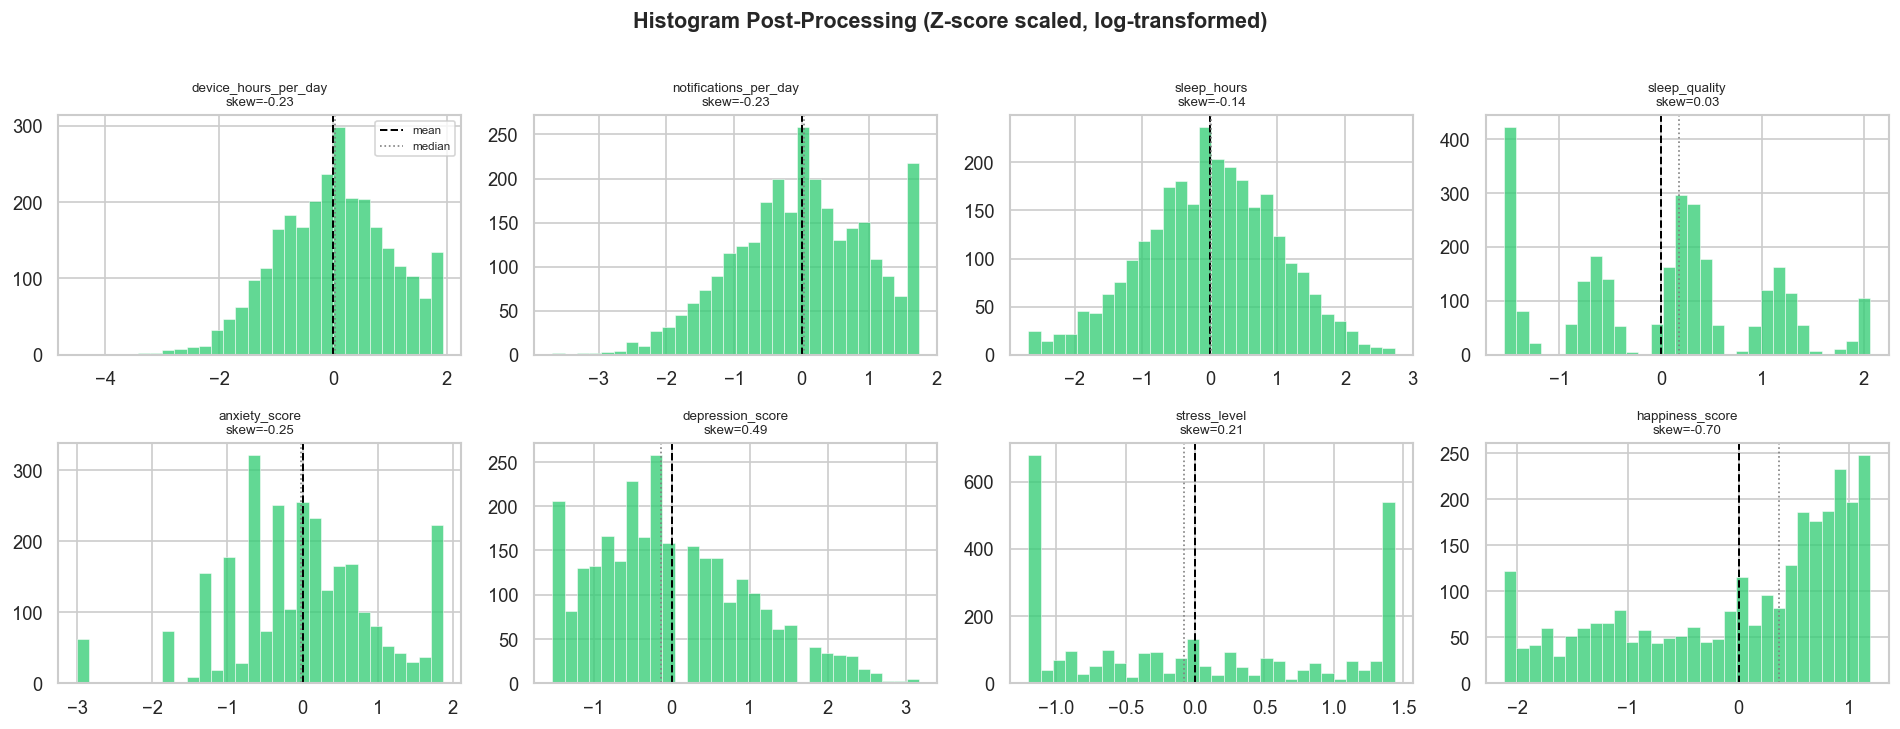

In [11]:
n_cols_p = 4
n_rows_p = int(np.ceil(len(num_scale_cols) / n_cols_p))
fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, n_rows_p * 3))
axes = axes.flatten()

for i, col in enumerate(num_scale_cols):
    ax = axes[i]
    ax.hist(X_train[col], bins=30, color='#2ECC71', alpha=0.75, edgecolor='white', lw=0.4)
    ax.axvline(X_train[col].mean(), color='black', lw=1.2, ls='--', label='mean')
    ax.axvline(X_train[col].median(), color='gray', lw=1.0, ls=':', label='median')
    ax.set_title(f'{col}\nskew={X_train[col].skew():.2f}', fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)

for j in range(len(num_scale_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histogram Post-Processing (Z-score scaled, log-transformed)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

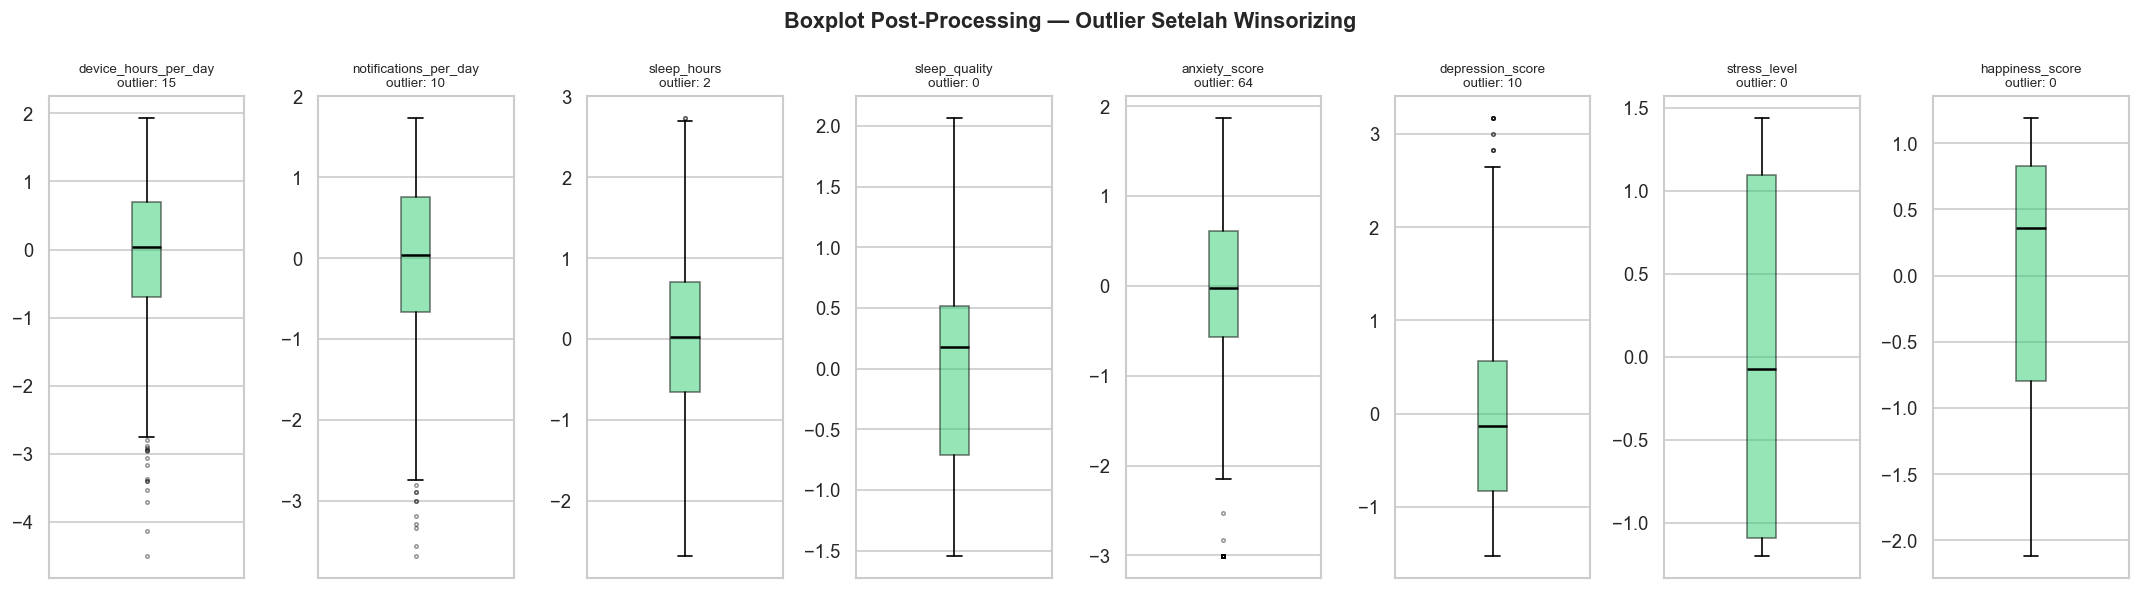

In [12]:
box_final = num_scale_cols[:8]

fig, axes = plt.subplots(1, len(box_final), figsize=(18, 5))

for ax, col in zip(axes, box_final):
    ax.boxplot(X_train[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#2ECC71', alpha=0.5),
               medianprops=dict(color='black', linewidth=1.5),
               flierprops=dict(marker='o', markersize=2, alpha=0.4))
    Q1_p, Q3_p = X_train[col].quantile([.25, .75])
    n_out_p = ((X_train[col] < Q1_p - 1.5*(Q3_p-Q1_p)) |
               (X_train[col] > Q3_p + 1.5*(Q3_p-Q1_p))).sum()
    ax.set_title(f'{col}\noutlier: {n_out_p}', fontsize=8)
    ax.set_xticks([])

plt.suptitle('Boxplot Post-Processing — Outlier Setelah Winsorizing',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

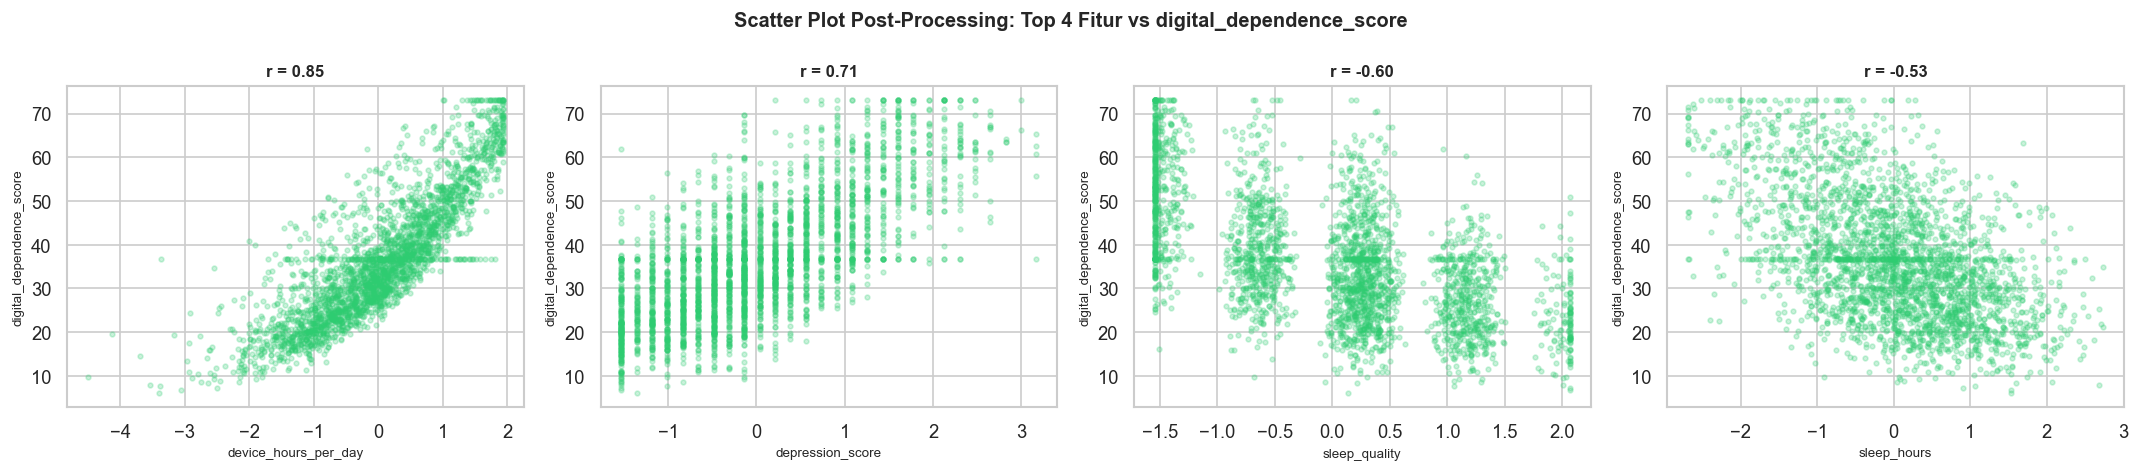

In [13]:
corr_final = X_train[num_scale_cols].corrwith(y_train).abs().sort_values(ascending=False)
top_scatter = corr_final.head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, feat in zip(axes, top_scatter):
    r = X_train[feat].corr(y_train)
    ax.scatter(X_train[feat], y_train, alpha=0.25, s=8, color='#2ECC71')
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel(TARGET, fontsize=8)
    ax.set_title(f'r = {r:.2f}', fontsize=10, fontweight='bold')

plt.suptitle(f'Scatter Plot Post-Processing: Top 4 Fitur vs {TARGET}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
print('       RINGKASAN DATA PROCESSING (FINAL)           ')
print('- ' * 33)
print(f'  Train set shape              : {X_train.shape}')
print(f'  Test  set shape              : {X_test.shape}')
print(f'  Kolom fitur akhir            : {list(X_train.columns)}')
print(f'  Kolom di-drop (multikolinear): {drop_multicolinear}')
print(f'  Kolom di-drop (tidak signifikan): {drop_insig}')
print(f'  Log1p-transform diterapkan   : {log_cols}')
print(f'  Sqrt-transform diterapkan    : {sqrt_cols}')
print(f'  Winsorizing diterapkan       : {list(winsor_bounds.keys())}')
print(f'  StandardScaler applied       : {num_scale_cols}')
print(f'  Missing values (train)       : {X_train.isnull().sum().sum()}')
print(f'  Missing values (test)        : {X_test.isnull().sum().sum()}')

       RINGKASAN DATA PROCESSING (FINAL)           
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  Train set shape              : (2800, 9)
  Test  set shape              : (700, 9)
  Kolom fitur akhir            : ['device_hours_per_day', 'notifications_per_day', 'sleep_hours', 'sleep_quality', 'anxiety_score', 'depression_score', 'stress_level', 'happiness_score', 'gender_Male']
  Kolom di-drop (multikolinear): ['phone_unlocks']
  Kolom di-drop (tidak signifikan): ['income_level_Lower-Mid', 'region_Europe', 'study_mins', 'social_media_mins', 'income_level_Upper-Mid', 'physical_activity_days', 'age', 'income_level_Low', 'daily_role', 'device_type_iPhone', 'device_type_Laptop', 'region_Middle East', 'device_type_Tablet', 'region_South America', 'region_Asia', 'region_North America', 'education_level']
  Log1p-transform diterapkan   : ['notifications_per_day', 'device_hours_per_day']
  Sqrt-transform diterapkan    : ['social_media_mins', 'anxiety_score', 'phone_unl

Modeling

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print('✅ Model berhasil dilatih.')
print(f'   Jumlah fitur yang digunakan : {X_train.shape[1]}')
print(f'   Ukuran train set            : {X_train.shape[0]} baris')
print(f'   Ukuran test set             : {X_test.shape[0]} baris')

✅ Model berhasil dilatih.
   Jumlah fitur yang digunakan : 9
   Ukuran train set            : 2800 baris
   Ukuran test set             : 700 baris


In [16]:
coef_df = pd.DataFrame({
    'Fitur': X_train.columns,
    'Koefisien': model.coef_
}).sort_values('Koefisien', key=abs, ascending=False)

print(f'Intercept (bias) : {model.intercept_:.4f}')
print('\nKoefisien per fitur (diurutkan dari pengaruh terbesar):')
print(coef_df.to_string(index=False))

Intercept (bias) : 35.9455

Koefisien per fitur (diurutkan dari pengaruh terbesar):
                Fitur  Koefisien
 device_hours_per_day   9.477244
notifications_per_day   4.987141
        anxiety_score   1.472649
     depression_score   1.346568
          gender_Male   1.033223
      happiness_score  -0.564829
          sleep_hours  -0.510497
         stress_level   0.288812
        sleep_quality  -0.179193


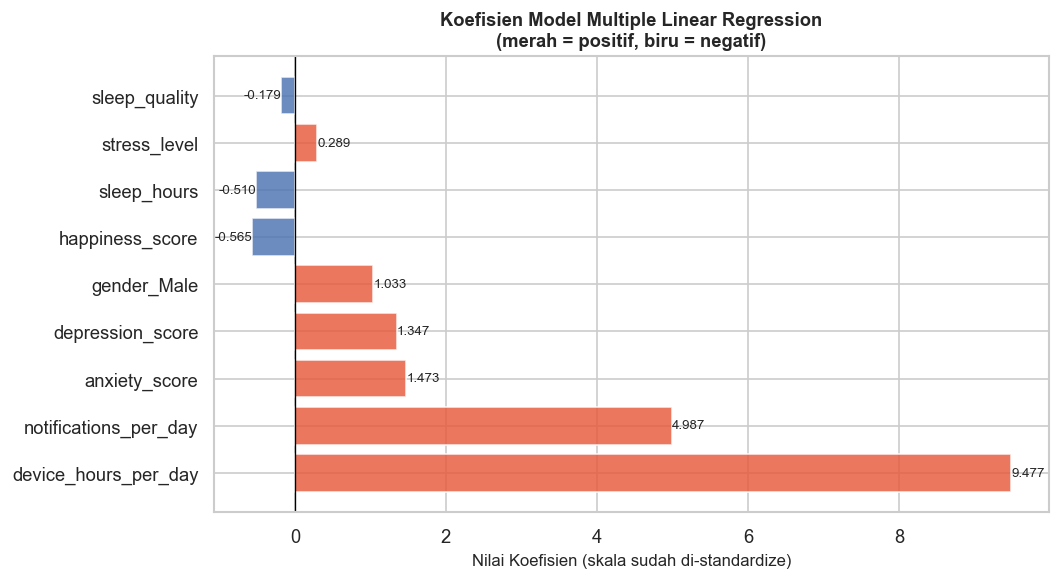

In [17]:
fig, ax = plt.subplots(figsize=(9, max(5, len(coef_df) * 0.38)))

colors = ['#E8593C' if v >= 0 else '#4C72B0' for v in coef_df['Koefisien']]
bars = ax.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors, alpha=0.82)

ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Nilai Koefisien (skala sudah di-standardize)')
ax.set_title('Koefisien Model Multiple Linear Regression\n(merah = positif, biru = negatif)',
             fontweight='bold')

for bar, val in zip(bars, coef_df['Koefisien']):
    x = bar.get_width() + 0.005 if val >= 0 else bar.get_width() - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(x, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', ha=ha, fontsize=8)

plt.tight_layout()
plt.show()

Evaluation

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def hitung_metrik(y_true, y_pred, label=''):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'Set': label, 'R²': r2, 'MAE': mae, 'RMSE': rmse}

metrik_train = hitung_metrik(y_train, y_pred_train, 'Train')
metrik_test = hitung_metrik(y_test, y_pred_test, 'Test')

metrik_df = pd.DataFrame([metrik_train, metrik_test]).set_index('Set')
print('=== Metrik Evaluasi ===')
print(metrik_df.round(4).to_string())

overfit = metrik_train['R²'] - metrik_test['R²']
print(f'\nSelisih R² train-test: {overfit:.4f}')
print('⚠ Selisih > 0.1 — kemungkinan ada overfitting ringan.' if overfit > 0.1 else '✅ Selisih ≤ 0.1 — model cukup general.')

=== Metrik Evaluasi ===
           R²     MAE    RMSE
Set                          
Train  0.8761  3.6971  4.9355
Test   0.8739  3.5886  4.8467

Selisih R² train-test: 0.0021
✅ Selisih ≤ 0.1 — model cukup general.


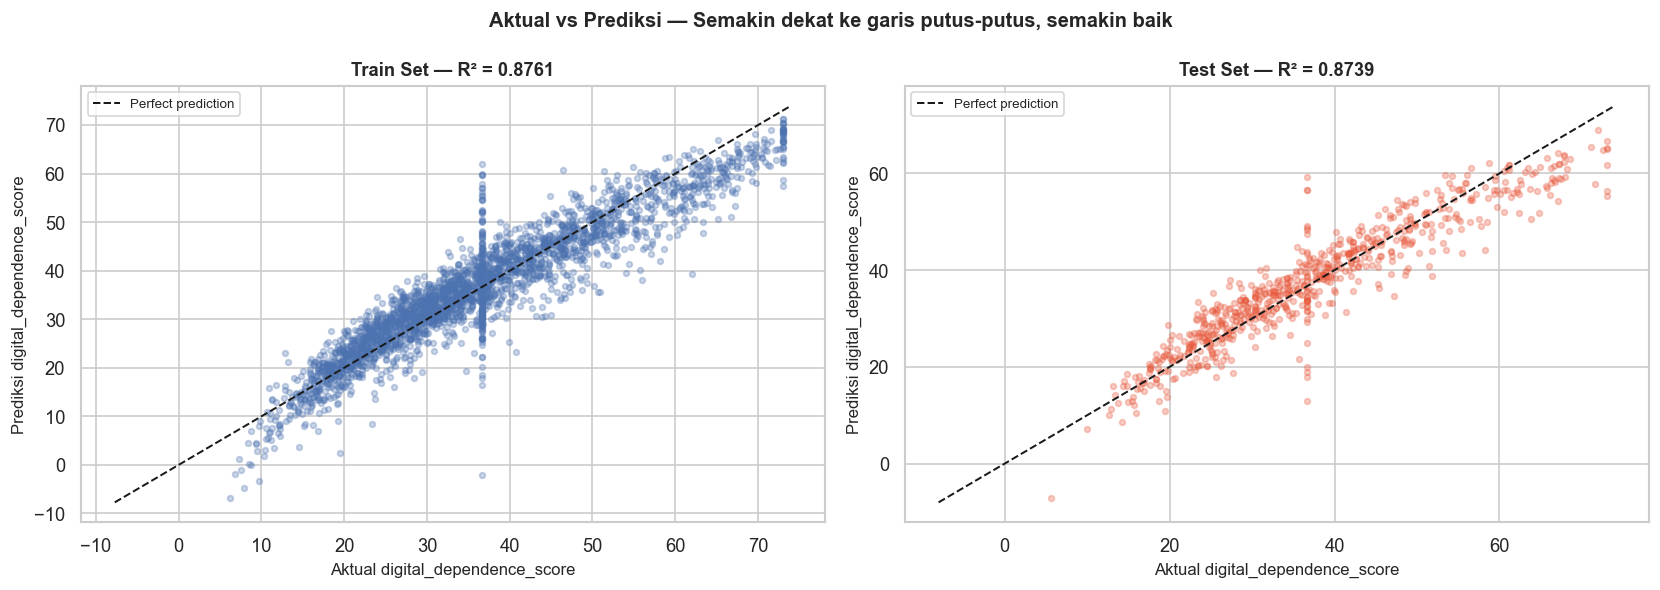

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_true, y_pred, label, color) in zip(axes, [
    (y_train, y_pred_train, 'Train', '#4C72B0'),
    (y_test, y_pred_test, 'Test', '#E8593C')
]):
    ax.scatter(y_true, y_pred, alpha=0.3, s=12, color=color)
    lims = [min(y_true.min(), y_pred.min()) - 1, max(y_true.max(), y_pred.max()) + 1]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Perfect prediction')
    r2 = r2_score(y_true, y_pred)
    ax.set_title(f'{label} Set — R² = {r2:.4f}', fontweight='bold')
    ax.set_xlabel(f'Aktual {TARGET}')
    ax.set_ylabel(f'Prediksi {TARGET}')
    ax.legend(fontsize=8)

fig.suptitle('Aktual vs Prediksi — Semakin dekat ke garis putus-putus, semakin baik',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
X_train_sm = sm.add_constant(X_train)
ols_final = sm.OLS(y_train, X_train_sm).fit()

sig_df = pd.DataFrame({
    'Koefisien': ols_final.params,
    'p_value': ols_final.pvalues,
}).drop('const', errors='ignore')

sig_df['Arah'] = sig_df['Koefisien'].apply(lambda x: '(+)' if x > 0 else '(-)')
sig_df['Signifikan'] = sig_df['p_value'] < 0.05

sig_only = sig_df[sig_df['Signifikan']].sort_values('Koefisien', key=abs, ascending=False)

print('Fitur Signifikan (p < 0.05):')
print(sig_only[['Koefisien', 'p_value', 'Arah']].round(4).to_string())

Fitur Signifikan (p < 0.05):
                       Koefisien  p_value Arah
device_hours_per_day      9.4772   0.0000  (+)
notifications_per_day     4.9871   0.0000  (+)
anxiety_score             1.4726   0.0000  (+)
depression_score          1.3466   0.0000  (+)
gender_Male               1.0332   0.0000  (+)
happiness_score          -0.5648   0.0000  (-)
sleep_hours              -0.5105   0.0000  (-)
stress_level              0.2888   0.0229  (+)


In [21]:
r2 = metrik_test['R²']


print('   RINGKASAN EVALUASI — MULTIPLE LINEAR REGRESSION')
print('- ' * 30)
print(f'  Target variabel   : {TARGET}')
print(f'  Jumlah fitur      : {X_train.shape[1]}')
print()
print(f'  R²   Train        : {metrik_train["R²"]:.4f}')
print(f'  R²   Test         : {metrik_test["R²"]:.4f}')
print(f'  MAE  Test         : {metrik_test["MAE"]:.4f}')
print(f'  RMSE Test         : {metrik_test["RMSE"]:.4f}')
print(f'  Selisih R² (train-test): {overfit:.4f} → {"Aman" if overfit <= 0.1 else "Periksa overfitting"}')
print()
print(f'  Fitur signifikan (p < 0.05): {len(sig_only)} dari {X_train.shape[1]}')
print()
print(f'  Interpretasi R² = {r2:.4f}:')
print(f'  Model menjelaskan {r2*100:.2f}% variasi {TARGET}.')
if r2 >= 0.7:
    print('  ✅ R² ≥ 0.70 — Model cukup baik.')
elif r2 >= 0.5:
    print('  ⚠ R² 0.50–0.70 — Model sedang, pertimbangkan penambahan fitur atau algoritma lain.')
else:
    print('  ❌ R² < 0.50 — Model kurang fit, pertimbangkan transformasi fitur atau algoritma non-linear.')

   RINGKASAN EVALUASI — MULTIPLE LINEAR REGRESSION
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  Target variabel   : digital_dependence_score
  Jumlah fitur      : 9

  R²   Train        : 0.8761
  R²   Test         : 0.8739
  MAE  Test         : 3.5886
  RMSE Test         : 4.8467
  Selisih R² (train-test): 0.0021 → Aman

  Fitur signifikan (p < 0.05): 8 dari 9

  Interpretasi R² = 0.8739:
  Model menjelaskan 87.39% variasi digital_dependence_score.
  ✅ R² ≥ 0.70 — Model cukup baik.


Simpan Model

In [22]:
import os
import pickle

SAVE_DIR = r'D:\Laravel\Flask-MachineLearning'
SAVE_PATH = os.path.join(SAVE_DIR, 'digital_dependence_model.pkl')

deployment_package = {
    'model': model,
    'scaler': scaler,
    'ohe': ohe,
    'ord_enc': ord_enc,
    'num_scale_cols': num_scale_cols,
    'feature_names': list(X_train.columns),
    'log_cols': log_cols,
    'sqrt_cols': sqrt_cols,
    'winsor_bounds': winsor_bounds,
    'target': TARGET,
    'drop_multicolinear': drop_multicolinear,
    'drop_insig': drop_insig,
}

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(deployment_package, f)

print(f'✅ Model berhasil disimpan ke:')
print(f'   {SAVE_PATH}')
print(f'\nIsi package yang disimpan:')
for key in deployment_package:
    print(f'  - {key}')

✅ Model berhasil disimpan ke:
   D:\Laravel\Flask-MachineLearning\digital_dependence_model.pkl

Isi package yang disimpan:
  - model
  - scaler
  - ohe
  - ord_enc
  - num_scale_cols
  - feature_names
  - log_cols
  - sqrt_cols
  - winsor_bounds
  - target
  - drop_multicolinear
  - drop_insig


load ulang

In [23]:
with open(SAVE_PATH, 'rb') as f:
    loaded = pickle.load(f)

print('✅ File .pkl berhasil dimuat kembali.')
print(f'   Fitur yang diharapkan model ({len(loaded["feature_names"])}):')
print(f'   {loaded["feature_names"]}')

sample = X_test.iloc[[0]]
pred_loaded = loaded['model'].predict(sample)[0]
pred_original = model.predict(sample)[0]

print(f'\nSanity check prediksi 1 sampel:')
print(f'  Prediksi model asli   : {pred_original:.4f}')
print(f'  Prediksi model loaded : {pred_loaded:.4f}')
print(f'  Hasil sama            : {abs(pred_original - pred_loaded) < 1e-8}')

✅ File .pkl berhasil dimuat kembali.
   Fitur yang diharapkan model (9):
   ['device_hours_per_day', 'notifications_per_day', 'sleep_hours', 'sleep_quality', 'anxiety_score', 'depression_score', 'stress_level', 'happiness_score', 'gender_Male']

Sanity check prediksi 1 sampel:
  Prediksi model asli   : 50.1227
  Prediksi model loaded : 50.1227
  Hasil sama            : True
